<a href="https://colab.research.google.com/github/Azansoh/medical-insurance-cost-prediction-ML/blob/main/MedicalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving insurance.csv to insurance.csv


In [ ]:
import pandas as pd

df=pd.read_csv("insurance.csv")

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
missing_values = df.isnull().sum()
print("Missing Values per Column:")
print(missing_values)

Missing Values per Column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")

# Optional: drop duplicates if any exist
df = df.drop_duplicates()

Number of duplicate rows: 1


In [ ]:
print("Before Preprocessing:")
print(df.dtypes)
print("\nUnique values in categorical columns:")
print("Sex:", df['sex'].unique())
print("Smoker:", df['smoker'].unique())
print("Region:", df['region'].unique())

Before Preprocessing:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Unique values in categorical columns:
Sex: ['female' 'male']
Smoker: ['yes' 'no']
Region: ['southwest' 'southeast' 'northwest' 'northeast']


In [ ]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

# Use One-Hot Encoding for the 'region' column
df = pd.get_dummies(df, columns=['region'], drop_first=True, dtype=int)

print("Categorical variables successfully encoded!")
df.head()

Categorical variables successfully encoded!


/tmp/ipykernel_3255/1246354307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex'] = df['sex'].map({'female': 0, 'male': 1})
/tmp/ipykernel_3255/1246354307.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [ ]:
print("Final Dataset Shape:", df.shape)
print("\nFinal Dataset Preview:")
df.head()

Final Dataset Shape: (1337, 9)

Final Dataset Preview:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

/tmp/ipykernel_3255/75034220.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


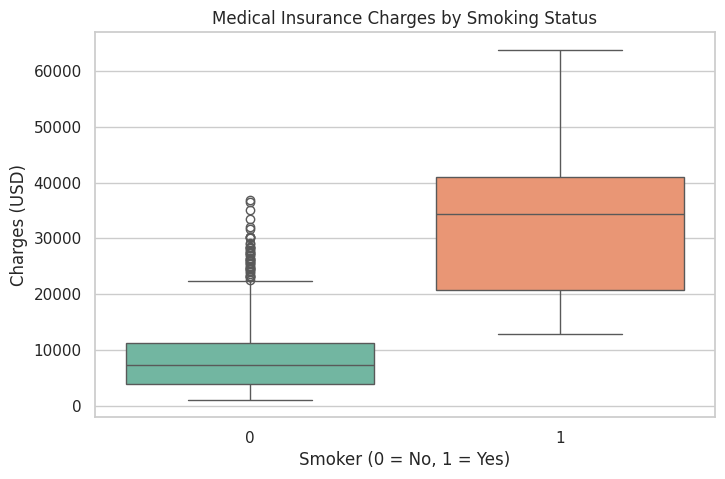

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Medical Insurance Charges by Smoking Status')
plt.xlabel('Smoker (0 = No, 1 = Yes)')
plt.ylabel('Charges (USD)')
plt.show()

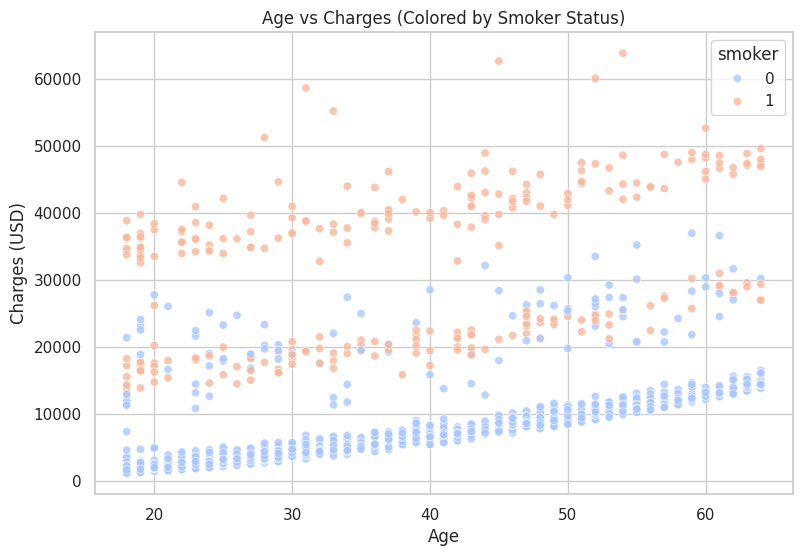

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, palette='coolwarm', alpha=0.8)
plt.title('Age vs Charges (Colored by Smoker Status)')
plt.xlabel('Age')
plt.ylabel('Charges (USD)')
plt.show()

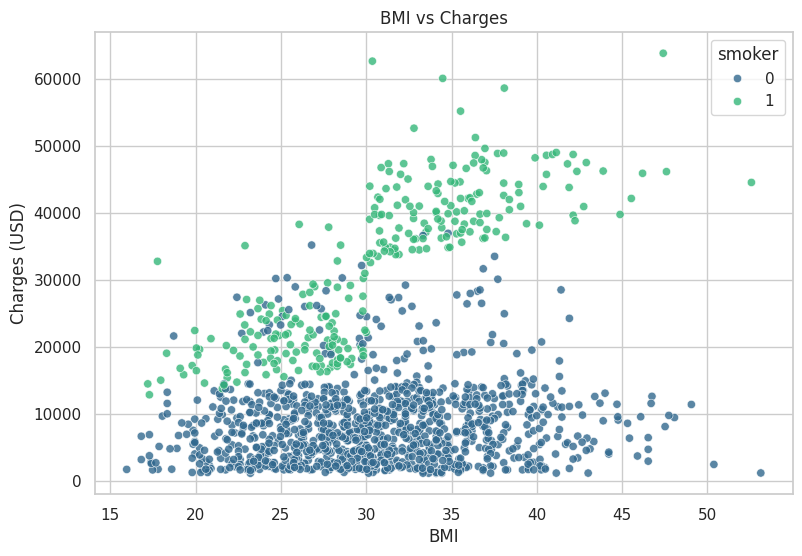

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, palette='viridis', alpha=0.8)
plt.title('BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.show()

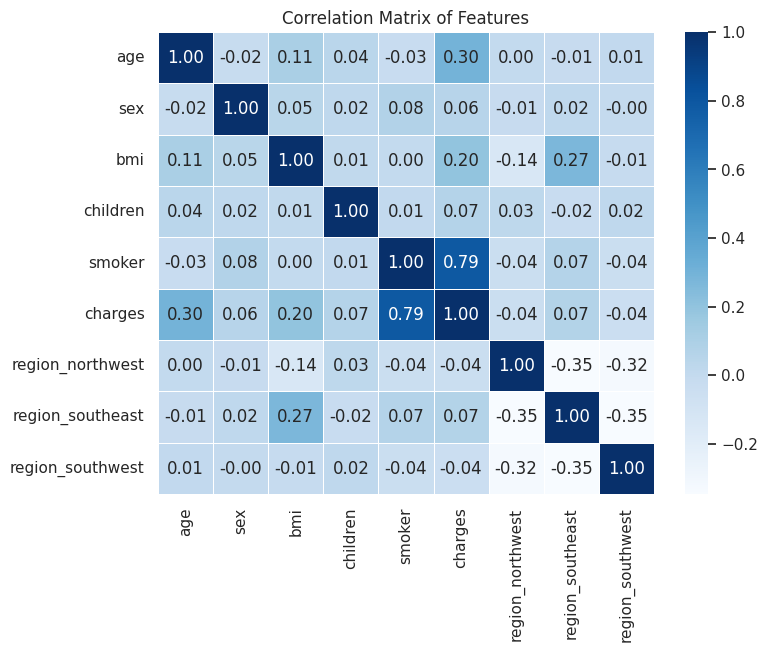


Exact Correlation with Charges:
charges             1.000000
smoker              0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex                 0.058044
region_northwest   -0.038695
region_southwest   -0.043637
Name: charges, dtype: float64


In [ ]:
plt.figure(figsize=(8, 6))

numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

print("\nExact Correlation with Charges:")
print(correlation_matrix['charges'].sort_values(ascending=False))

In [ ]:
print("""
Important Observations Discovered:
1. Smoking Status is the Strongest Predictor: Smokers have drastically higher medical charges overall compared to non-smokers, showing a very clear division in cost structures.
2. Age Correlation: Insurance charges increase steadily with age for both smokers and non-smokers, creating upward-sloping bands in scatter plots.
3. BMI Impact: Higher BMI (especially above 30, indicating obesity) combined with smoking results in the highest spikes in medical charges.
4. Correlation Analysis: The correlation matrix confirms that 'smoker' has the highest positive linear correlation with 'charges', followed closely by 'age' and 'bmi'.
""")


Important Observations Discovered:
1. Smoking Status is the Strongest Predictor: Smokers have drastically higher medical charges overall compared to non-smokers, showing a very clear division in cost structures.
2. Age Correlation: Insurance charges increase steadily with age for both smokers and non-smokers, creating upward-sloping bands in scatter plots.
3. BMI Impact: Higher BMI (especially above 30, indicating obesity) combined with smoking results in the highest spikes in medical charges.
4. Correlation Analysis: The correlation matrix confirms that 'smoker' has the highest positive linear correlation with 'charges', followed closely by 'age' and 'bmi'.



In [ ]:
X = df.drop(columns=['charges'])
y = df['charges']

print("Features (X) Shape:", X.shape)
print("Target (y) Shape:", y.shape)
X.head()


Features (X) Shape: (1337, 8)
Target (y) Shape: (1337,)


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,1
1,18,1,33.770,1,0,0,1,0
2,28,1,33.000,3,0,0,1,0
3,33,1,22.705,0,0,1,0,0
4,32,1,28.880,0,0,1,0,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1069, 8)
Testing set shape: (268, 8)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

print("Linear Regression model initialized successfully!")

Linear Regression model initialized successfully!


In [ ]:
model.fit(X_train, y_train)

print("Model successfully trained on training data!")
print("Model Intercept (c):", model.intercept_)
print("Model Coefficients (m):", model.coef_)

Model successfully trained on training data!
Model Intercept (c): -11092.652295945947
Model Coefficients (m): [  248.21072022  -101.54205399   318.70144095   533.0099888
 23077.76459287  -391.76145478  -838.91961573  -659.13975155]


In [ ]:
y_pred = model.predict(X_test)

# Display a comparison of actual vs predicted values for the first 5 test samples
import pandas as pd
comparison_df = pd.DataFrame({'Actual Charges': y_test.values[:5], 'Predicted Charges': y_pred[:5]})
print(comparison_df)

   Actual Charges  Predicted Charges
0      8688.85885        8143.693884
1      5708.86700        5737.115683
2     11436.73815       14369.314876
3     38746.35510       31745.513636
4      4463.20510        8962.386657


In [ ]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 4177.05
Mean Squared Error (MSE): 35478020.68
Root Mean Squared Error (RMSE): 5956.34
R² Score: 0.8069


In [ ]:
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 4177.045561036318


In [ ]:
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Squared Error (MSE): 35478020.67523558
Root Mean Squared Error (RMSE): 5956.342894363585


In [ ]:
print("R² Score:", r2)

R² Score: 0.8069287081198013


Sample of Actual vs Predicted Results:
   Actual Charges  Predicted Charges
0      8688.85885        8143.693884
1      5708.86700        5737.115683
2     11436.73815       14369.314876
3     38746.35510       31745.513636
4      4463.20510        8962.386657
5      9304.70190       13149.722353
6     38511.62830       30446.760679
7      2150.46900        1453.288813
8      7345.72660       10633.018402
9     10264.44210       11318.943794


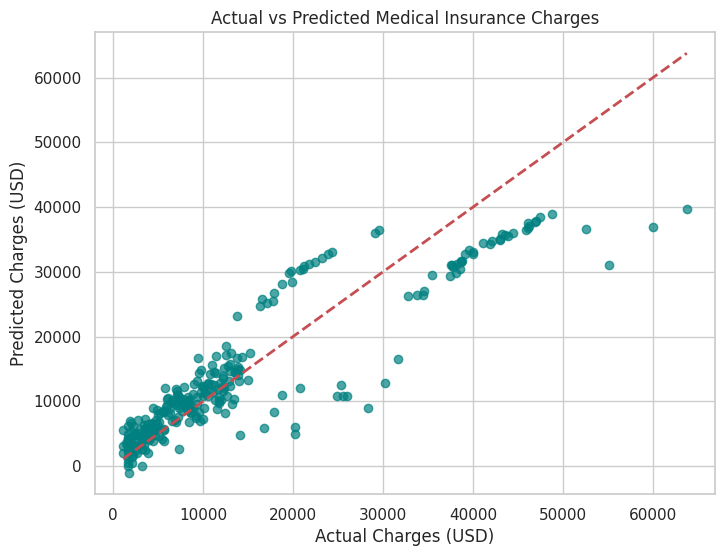

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt


results_df = pd.DataFrame({'Actual Charges': y_test.values, 'Predicted Charges': y_pred})
print("Sample of Actual vs Predicted Results:")
print(results_df.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.xlabel('Actual Charges (USD)')
plt.ylabel('Predicted Charges (USD)')
plt.title('Actual vs Predicted Medical Insurance Charges')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect fit line
plt.show()

In [ ]:

def predict_insurance_cost(age, sex, bmi, children, smoker, region_northwest, region_southeast, region_southwest):
    """
    Function to take raw customer inputs, format them to match the model's training columns,
    and output the predicted medical insurance charge.
    """
    import pandas as pd


    input_data = pd.DataFrame([[
        age, sex, bmi, children, smoker,
        region_northwest, region_southeast, region_southwest
    ]], columns=X.columns)

    # Predict cost using the trained model
    predicted_cost = model.predict(input_data)[0]
    return predicted_cost

cost_1 = predict_insurance_cost(30, 1, 32.5, 2, 1, 0, 1, 0)
print("=== Test Case 1 (Smoker Profile) ===")
print("Input Features: Age: 30, Sex: Male, BMI: 32.5, Children: 2, Smoker: Yes, Region: Southeast")
print(f"Predicted Medical Insurance Cost: ${cost_1:.2f}\n")


cost_2 = predict_insurance_cost(45, 0, 24.0, 1, 0, 1, 0, 0)
print("=== Test Case 2 (Non-Smoker Profile) ===")
print("Input Features: Age: 45, Sex: Female, BMI: 24.0, Children: 1, Smoker: No, Region: Northwest")
print(f"Predicted Medical Insurance Cost: ${cost_2:.2f}")

=== Test Case 1 (Smoker Profile) ===
Input Features: Age: 30, Sex: Male, BMI: 32.5, Children: 2, Smoker: Yes, Region: Southeast
Predicted Medical Insurance Cost: $29914.79

=== Test Case 2 (Non-Smoker Profile) ===
Input Features: Age: 45, Sex: Female, BMI: 24.0, Children: 1, Smoker: No, Region: Northwest
Predicted Medical Insurance Cost: $7866.91
